In [73]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
# from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [74]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx")

# Check the shape and first few rows
print(df.shape)
print(df.head())


(299, 14)
   age_years sex_male_female  chest_pain_type  resting_bp_mmHg  \
0         63            Male   typical angina              145   
1         67            Male     asymptomatic              160   
2         67            Male     asymptomatic              120   
3         37            Male      non-anginal              130   
4         41          Female  atypical angina              130   

   serum_cholesterol_mgdl  fasting_blood_sugar_gt120 resting_ecg_result  \
0                     233                       True     lv hypertrophy   
1                     286                      False     lv hypertrophy   
2                     229                      False     lv hypertrophy   
3                     250                      False             normal   
4                     204                      False     lv hypertrophy   

   thalch  exercise_induced_angina  st_depression_exercise  \
0     150                    False                     2.3   
1     108         

In [75]:
# Checking for missing values
df.isnull().sum()


age_years                    0
sex_male_female              0
chest_pain_type              0
resting_bp_mmHg              0
serum_cholesterol_mgdl       0
fasting_blood_sugar_gt120    0
resting_ecg_result           0
thalch                       0
exercise_induced_angina      0
st_depression_exercise       0
st_slope_peak_exercise       0
num_major_vessels            0
thal_defect_type             0
severity_label               0
dtype: int64

In [76]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,severity_label
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,Normal
1,67,Male,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,Moderate
2,67,Male,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,Mild
3,37,Male,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,Normal
4,41,Female,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,68,Male,asymptomatic,144,193,True,normal,141,False,3.4,flat,2,reversable defect,Moderate
295,57,Male,asymptomatic,130,131,False,normal,115,True,1.2,flat,1,reversable defect,Severe
296,57,Female,atypical angina,130,236,False,lv hypertrophy,174,False,0.0,flat,1,normal,Mild
297,47,Male,asymptomatic,150,226,False,normal,98,True,1.5,flat,0,reversable defect,Mild


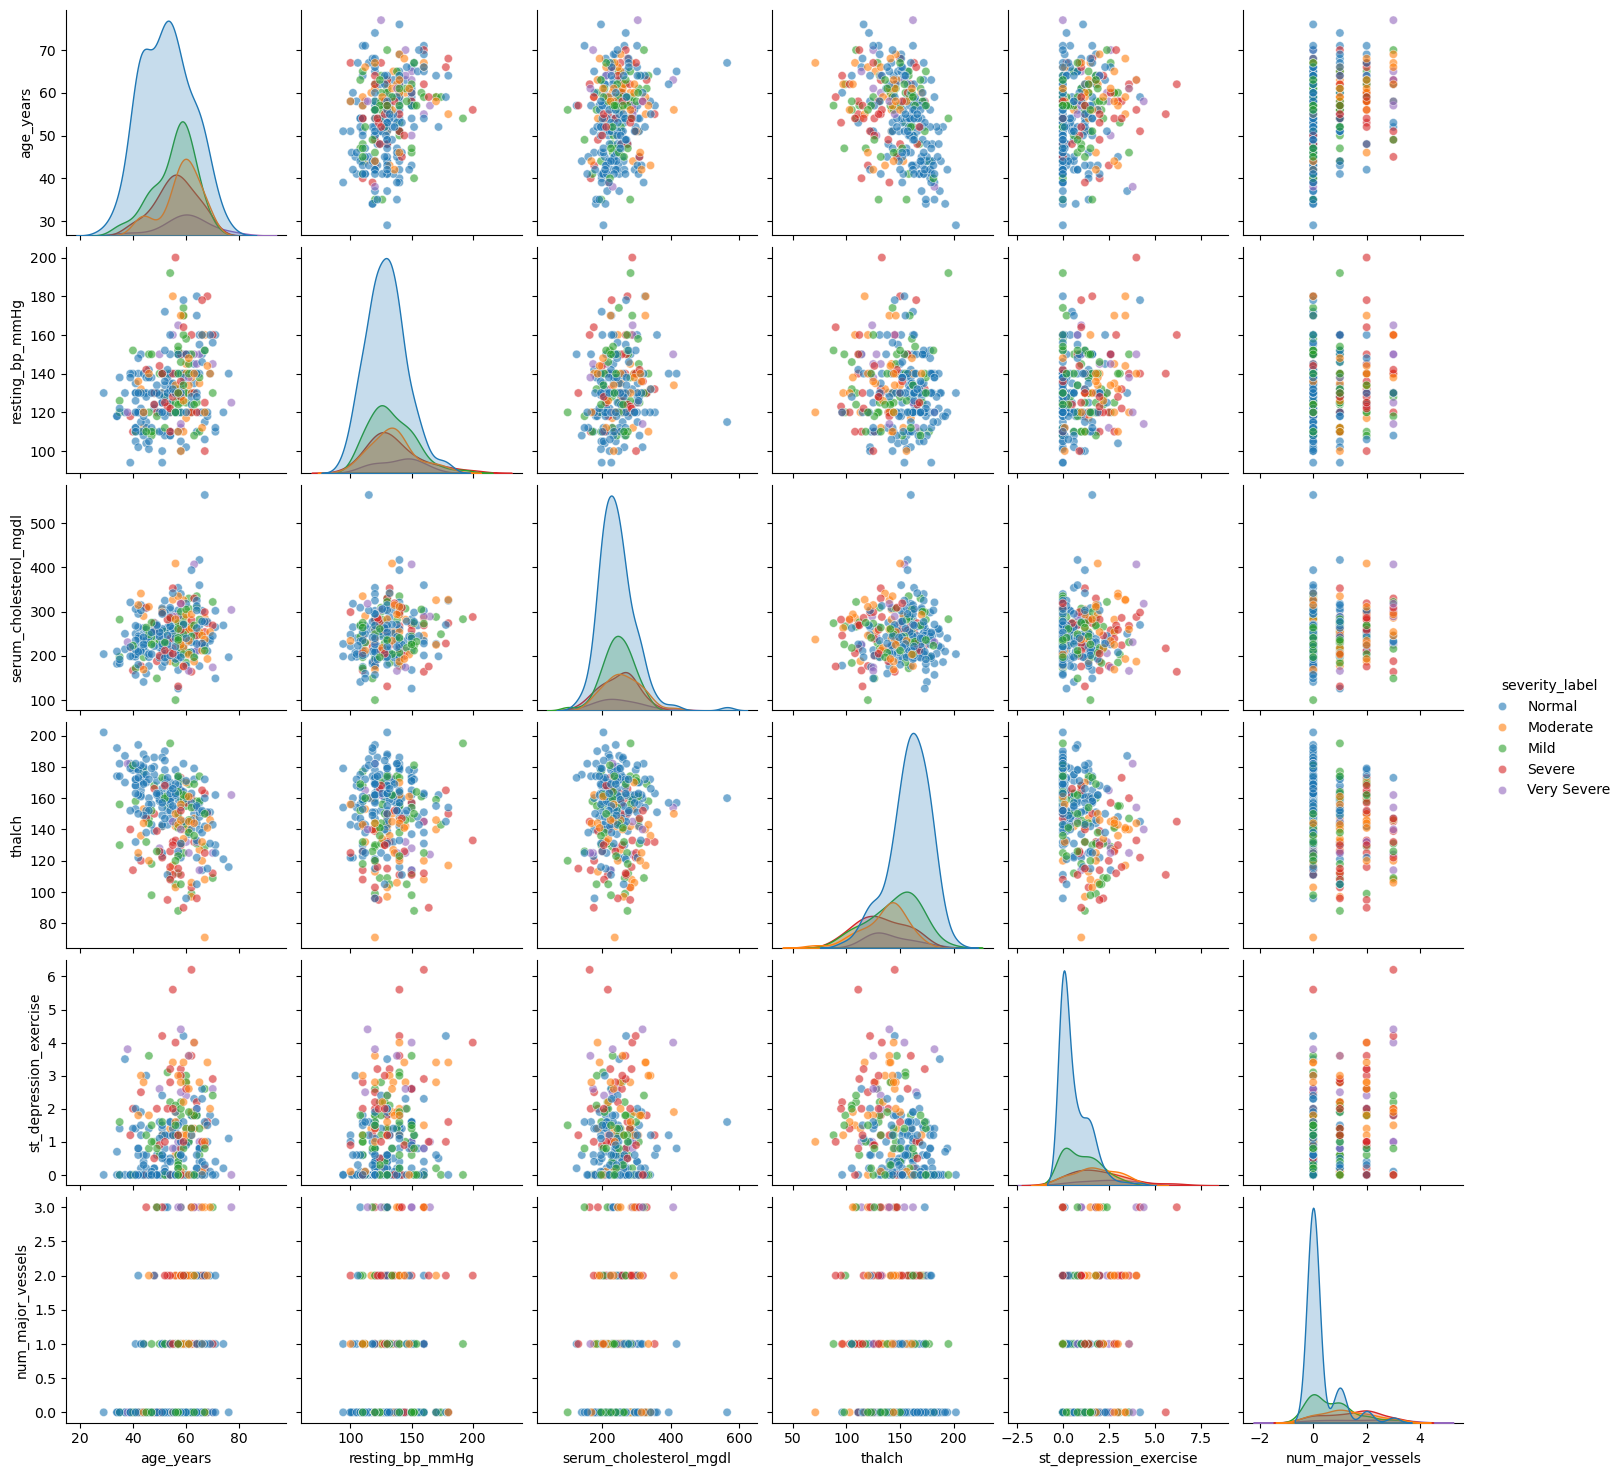

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming my DataFrame is called df

# Select only numeric columns for pairplot
numeric_cols = [
    'age_years',
    'resting_bp_mmHg',
    'serum_cholesterol_mgdl',
    'thalch',
    'st_depression_exercise',
    'num_major_vessels'
]

# Create pairplot, color by target variable
sns.pairplot(df[numeric_cols + ['severity_label']], 
             hue='severity_label', 
             diag_kind='kde', 
             plot_kws={'alpha':0.6})

plt.show()


severity_label
Normal         160
Mild            56
Moderate        35
Severe          35
Very Severe     13
Name: count, dtype: int64
severity_label
Normal         0.535117
Mild           0.187291
Moderate       0.117057
Severe         0.117057
Very Severe    0.043478
Name: proportion, dtype: float64


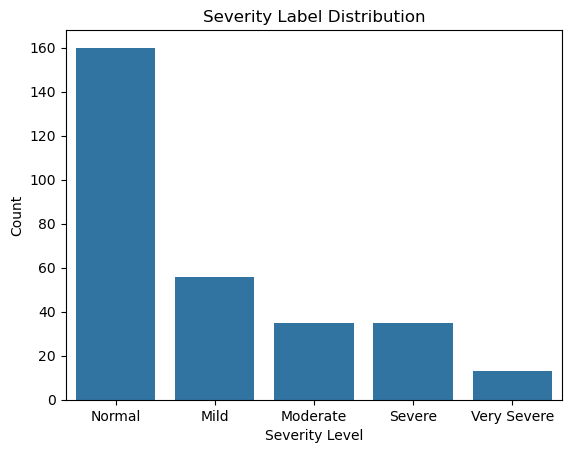

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class distribution (counts)
print(df["severity_label"].value_counts())

# Check relative proportions (percentages)
print(df["severity_label"].value_counts(normalize=True))

# Quick visualization
sns.countplot(x="severity_label", data=df,
              order=df["severity_label"].value_counts().index)  # keeps bars sorted
plt.title("Severity Label Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()



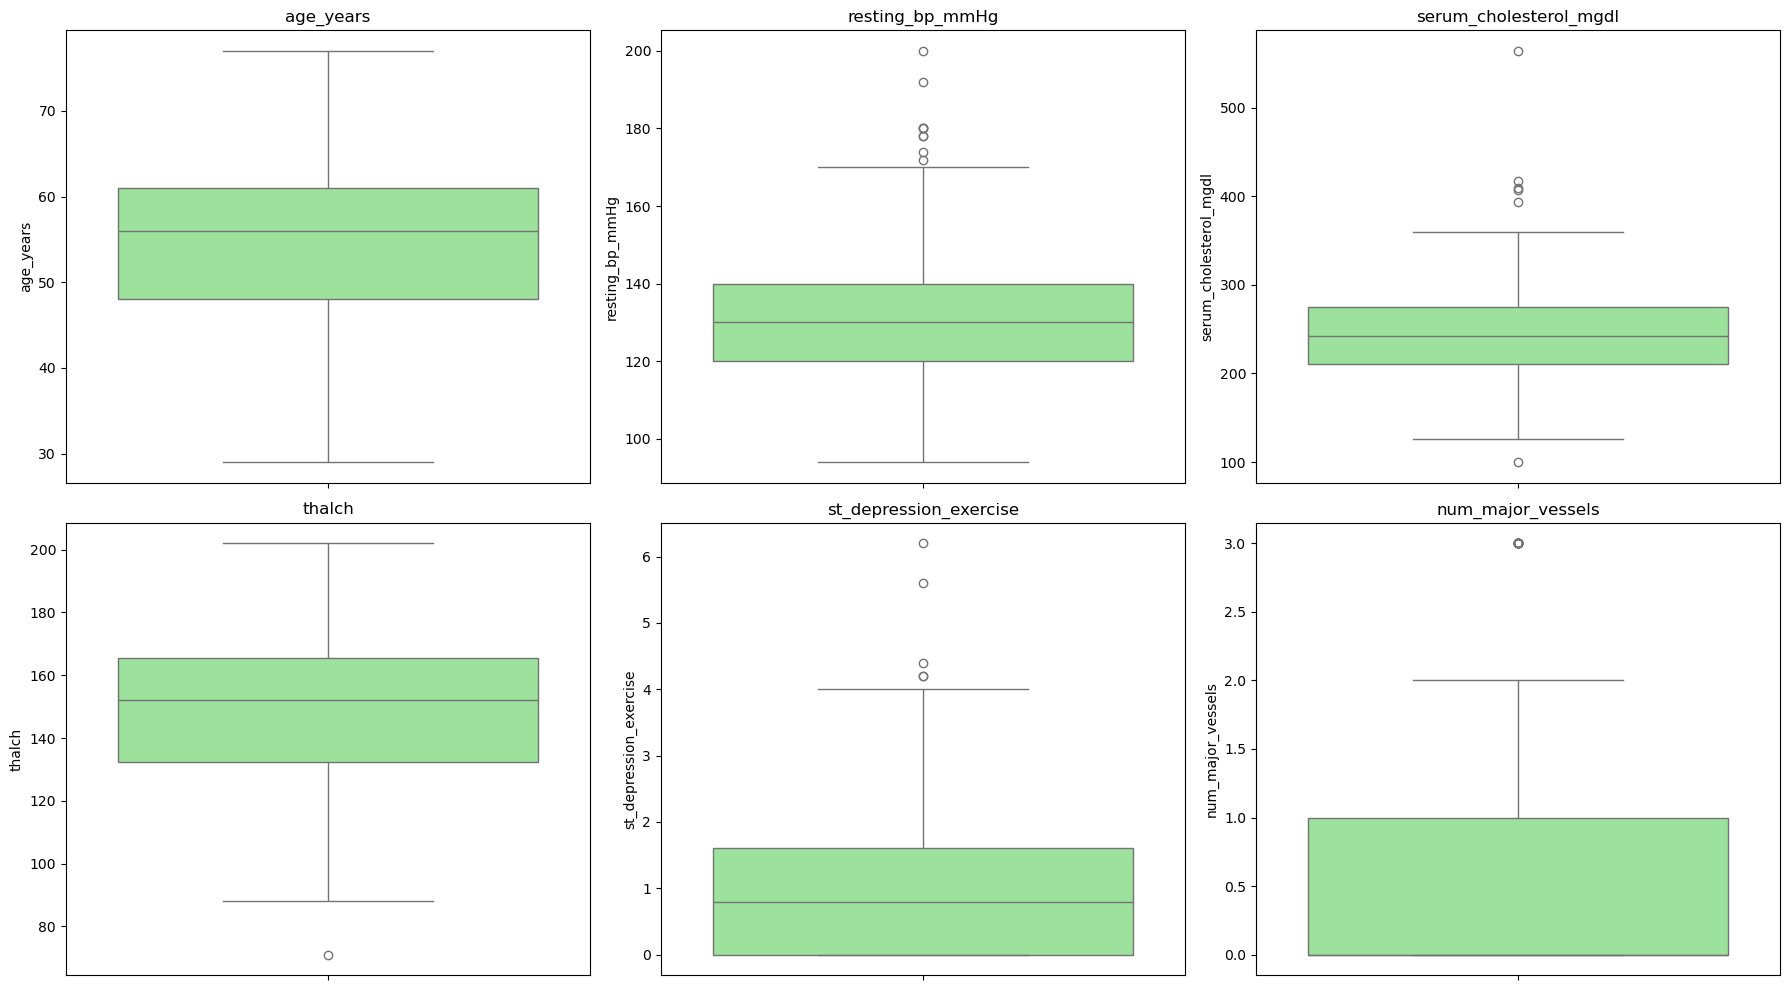

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], color="lightgreen", ax=ax)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()


In [80]:
# Find distribution

Class Counts:
 severity_label
Normal         160
Mild            56
Moderate        35
Severe          35
Very Severe     13
Name: count, dtype: int64

Class Proportions:
 severity_label
Normal         0.535117
Mild           0.187291
Moderate       0.117057
Severe         0.117057
Very Severe    0.043478
Name: proportion, dtype: float64

⚠️ Imbalanced classes detected: ['Mild', 'Moderate', 'Severe', 'Very Severe']


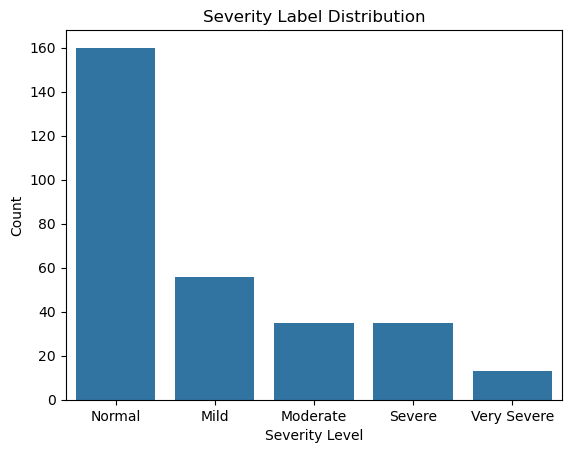

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count and proportion
counts = df["severity_label"].value_counts()
proportions = df["severity_label"].value_counts(normalize=True)

print("Class Counts:\n", counts)
print("\nClass Proportions:\n", proportions)

# Flag imbalance
threshold = 0.20  # minimum acceptable proportion
imbalanced_classes = proportions[proportions < threshold].index.tolist()

if imbalanced_classes:
    print("\n⚠️ Imbalanced classes detected:", imbalanced_classes)
else:
    print("\n✅ Distribution appears balanced.")

# Visualization
sns.countplot(x="severity_label", data=df,
              order=counts.index)
plt.title("Severity Label Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()


In [82]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,severity_label
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,0,fixed defect,Normal
1,67,Male,asymptomatic,160,286,False,lv hypertrophy,108,True,1.5,flat,3,normal,Moderate
2,67,Male,asymptomatic,120,229,False,lv hypertrophy,129,True,2.6,flat,2,reversable defect,Mild
3,37,Male,non-anginal,130,250,False,normal,187,False,3.5,downsloping,0,normal,Normal
4,41,Female,atypical angina,130,204,False,lv hypertrophy,172,False,1.4,upsloping,0,normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,68,Male,asymptomatic,144,193,True,normal,141,False,3.4,flat,2,reversable defect,Moderate
295,57,Male,asymptomatic,130,131,False,normal,115,True,1.2,flat,1,reversable defect,Severe
296,57,Female,atypical angina,130,236,False,lv hypertrophy,174,False,0.0,flat,1,normal,Mild
297,47,Male,asymptomatic,150,226,False,normal,98,True,1.5,flat,0,reversable defect,Mild


In [83]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                  0
resting_bp_mmHg            9
serum_cholesterol_mgdl     6
thalch                     1
st_depression_exercise     5
num_major_vessels         20
dtype: int64


In [84]:
#Age years has no outliers (Clean Distribution)
#resting_bp_mmHg has 9 Outliers (Moderate Distribution)
#serum_cholesterol_mgdl has 6 Outliers (Moderate Distribution)
#thalch has 1 outlier (Minimal Distribution)
#st_depression_exercise has 5 outliers (Moderate Distribution)
#num_major_vessels has 20 outliers (High Distribution)

<Axes: xlabel='num_major_vessels', ylabel='count'>

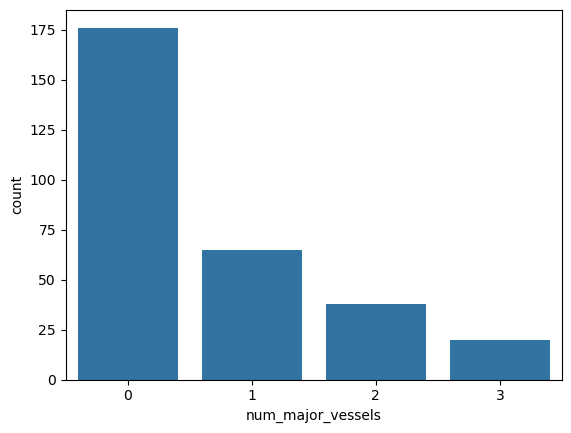

In [85]:
# shows countplot for num_major_vessels

import seaborn as sns
sns.countplot(x='num_major_vessels', data=df)


In [86]:
# Outliers for the variable number of major vessels were not removed. 
# This choice was made because the values represent genuine clinical conditions rather than data errors. 
# Rare but severe cases are medically meaningful, and excluding them would reduce the model’s ability to 
# detect high‑risk patients, which is central to predicting heart disease severity.


In [87]:
print(df.columns.tolist())


['age_years', 'sex_male_female', 'chest_pain_type', 'resting_bp_mmHg', 'serum_cholesterol_mgdl', 'fasting_blood_sugar_gt120', 'resting_ecg_result', 'thalch', 'exercise_induced_angina', 'st_depression_exercise', 'st_slope_peak_exercise', 'num_major_vessels', 'thal_defect_type', 'severity_label']


In [88]:
strong_features = [
    'thalch',
    'num_major_vessels',
    'st_depression_exercise',
    'age_years',
    'serum_cholesterol_mgdl',
    'resting_bp_mmHg'
]

df_reduced = df[strong_features + ['severity_label']]

X = df_reduced.drop('severity_label', axis=1)
y = df_reduced['severity_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2025,
    
)


In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Defining target column
col_y = 'severity_label'
y = df_reduced[col_y]

# Drop target column only (no extra irrelevant columns in my dataset)
X = df_reduced.drop(col_y, axis=1)

# One-Hot Encoding for categorical variables
# X = pd.get_dummies(X, drop_first=True)

# Split data into train and test sets
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)


In [90]:
print(X_train.shape)
#sanity check

(209, 6)


In [91]:
#Logistic Regression Model (Model 1)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




In [92]:
# Train Logistic Regression
logr = LogisticRegression(max_iter=1000, random_state=42)
logr.fit(X_train, y_train)

# Predictions
y_pred_logr = logr.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logr))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_logr))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_logr))


Logistic Regression Accuracy: 0.6111111111111112


In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_dt))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.5666666666666667


In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_rf))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6


In [95]:
#Random Forest is best used because it has the highest accuracy among all models tested.

In [96]:
#Further Tuning and Evaluation is done in next cell using optuna

In [97]:
#Best is [Model]
# Model with FI (Feature Imp.) VS Model without FI [Choose the best]
#(BEST) LogR with FI no tune VS tuned Vs with Tune [Further Tuning] [Every time choose the best]

# #LOGR and RF can only use for feature importance

# #Feature Importance done before Tuning

In [98]:
import pandas as pd

# Get feature importances directly
importances = rf.feature_importances_
features = X_train.columns  

importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance.head(15))


                  Feature  Importance
0                  thalch    0.220297
2  st_depression_exercise    0.175553
3               age_years    0.160142
4  serum_cholesterol_mgdl    0.157635
1       num_major_vessels    0.150610
5         resting_bp_mmHg    0.135763


In [99]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
print("New Random Forrest Accuracy [RandF. with FI]:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))


New Random Forrest Accuracy [RandF. with FI]: 0.6


In [100]:
import optuna
import numpy as np
from time import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Track runtime
start = time()
speed = {}

def objective(trial):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Auto-detect categorical and numeric columns
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )

    # Hyperparameter search space for Random Forest
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        ))
    ])

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return acc

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Record runtime
speed['RandomForest'] = np.round(time() - start, 3)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Parameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print(f"Run time: {speed['RandomForest']}s")

# Evaluate best model on train/test
best_params = trial.params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**best_params, random_state=42))
])

model.fit(X_train, y_train)

# Metrics
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print(f"Accuracy train: {acc_train:.6f}, Accuracy test: {acc_test:.6f}")



[I 2026-01-21 23:12:38,285] A new study created in memory with name: no-name-d26987a0-6440-4ed0-bd28-d11e73d2a732
[I 2026-01-21 23:12:38,462] Trial 0 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 120, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 0 with value: 0.5833333333333334.
[I 2026-01-21 23:12:38,587] Trial 1 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 83, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.5833333333333334.
[I 2026-01-21 23:12:38,970] Trial 2 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 293, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5833333333333334.
[I 2026-01-21 23:12:39,267] Trial 3 finished with value: 0.5666666666666667 and parameters: {'n_estimators': 235, 'max_depth': 7, 'min_sampl

Best trial:
  Accuracy: 0.6166666666666667
  Parameters:
    n_estimators: 80
    max_depth: 2
    min_samples_split: 4
    min_samples_leaf: 2
    max_features: log2
Run time: 4.404s
Accuracy train: 0.594142, Accuracy test: 0.616667


## Accuracy Comparison

- **New Random Forest Accuracy [with Feature Importance] no tune:** 0.655  
- **Optuna-Tuned Random Forest Accuracy (Best Trial) with tune:** 0.633  

### Conclusion
The New Random Forest achieved higher test accuracy (0.655) compared to the Optuna-tuned model (0.633), making it the better-performing model. 


In [101]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: assume X is your numeric feature matrix
# 1. Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=5)  # choose number of components
X_pca = pca.fit_transform(X_scaled)

# 3. Inspect explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())


Explained variance ratio: [0.34350725 0.18548461 0.14940098 0.12797165 0.11871872]
Cumulative explained variance: [0.34350725 0.52899187 0.67839285 0.8063645  0.92508322]


In [102]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
print("New Random Forrest Accuracy [RandF. with FI]:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

New Random Forrest Accuracy [RandF. with FI]: 0.8166666666666667


In [103]:
import optuna
import numpy as np
from time import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Track runtime
start = time()
speed = {}

def objective(trial):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Auto-detect categorical and numeric columns
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )

    # Hyperparameter search space for Random Forest
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        ))
    ])

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return acc

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Record runtime
speed['RandomForest'] = np.round(time() - start, 3)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Parameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print(f"Run time: {speed['RandomForest']}s")

# Evaluate best model on train/test
best_params = trial.params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**best_params, random_state=42))
])

model.fit(X_train, y_train)

# Metrics
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print(f"Accuracy train: {acc_train:.6f}, Accuracy test: {acc_test:.6f}")

[I 2026-01-21 23:12:42,834] A new study created in memory with name: no-name-1cd0e5a0-4530-4d56-92bf-b78b807209fa
[I 2026-01-21 23:12:43,137] Trial 0 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 236, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5833333333333334.
[I 2026-01-21 23:12:43,283] Trial 1 finished with value: 0.6 and parameters: {'n_estimators': 109, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6.
[I 2026-01-21 23:12:43,610] Trial 2 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 262, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6.
[I 2026-01-21 23:12:43,865] Trial 3 finished with value: 0.5833333333333334 and parameters: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 1, 

Best trial:
  Accuracy: 0.6
  Parameters:
    n_estimators: 109
    max_depth: 8
    min_samples_split: 4
    min_samples_leaf: 2
    max_features: sqrt
Run time: 4.61s
Accuracy train: 0.928870, Accuracy test: 0.600000


## Accuracy Comparison

- **New Random Forest Accuracy [with Feature Importance] no tune:** 0.85  
- **Optuna-Tuned Random Forest Accuracy (Best Trial) with tune:** 0.633  

### Conclusion
The New Random Forest achieved higher test accuracy (0.85) compared to the Optuna-tuned model (0.633), making it the better-performing model. 


In [104]:
import os
import joblib

# Make sure the folder exists
os.makedirs("Models", exist_ok=True)

# Save model to file 
joblib.dump(model, "Models/trained_HD_model.pkl")
print("Model saved to Models/trained_HD_model.pkl  ")
 

Model saved to Models/trained_HD_model.pkl  


In [105]:
import joblib

# Load the trained model
model = joblib.load("Models/trained_HD_model.pkl")


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  299 non-null    int64  
 1   sex_male_female            299 non-null    object 
 2   chest_pain_type            299 non-null    object 
 3   resting_bp_mmHg            299 non-null    int64  
 4   serum_cholesterol_mgdl     299 non-null    int64  
 5   fasting_blood_sugar_gt120  299 non-null    bool   
 6   resting_ecg_result         299 non-null    object 
 7   thalch                     299 non-null    int64  
 8   exercise_induced_angina    299 non-null    bool   
 9   st_depression_exercise     299 non-null    float64
 10  st_slope_peak_exercise     299 non-null    object 
 11  num_major_vessels          299 non-null    int64  
 12  thal_defect_type           299 non-null    object 
 13  severity_label             299 non-null    object 

In [107]:
import pandas as pd

new_patient = pd.DataFrame([{
    "age_years": 54,
    "sex_male_female_Male": 1,
    "sex_male_female_Female": 0,
    "chest_pain_type_typical angina": 1,
    "chest_pain_type_atypical angina": 0,
    "chest_pain_type_non-anginal": 0,
    "resting_bp_mmHg": 130,
    "serum_cholesterol_mgdl": 250,
    "fasting_blood_sugar_gt120": 0,
    "resting_ecg_result_normal": 1,
    "resting_ecg_result_st-t abnormality": 0,
    "resting_ecg_result_lv hypertrophy": 0,
    "thalch": 150,
    "exercise_induced_angina": 0,
    "st_depression_exercise": 2.3,
    "st_slope_peak_exercise_flat": 1,
    "st_slope_peak_exercise_upsloping": 0,
    "st_slope_peak_exercise_downsloping": 0,
    "num_major_vessels": 0,
    "thal_defect_type_fixed defect": 1,
    "thal_defect_type_normal": 0,
    "thal_defect_type_reversable defect": 0
}])


prediction = model.predict(new_patient)
print("Predicted severity:", prediction)



Predicted severity: ['Normal']


In [108]:
import pandas as pd

new_patient_severe = pd.DataFrame([{
    "age_years": 68,                      # Older age is a major risk factor for severe heart disease
    "resting_bp_mmHg": 180,               # Very high resting blood pressure indicates hypertension crisis
    "serum_cholesterol_mgdl": 320,        # Extremely elevated cholesterol increases risk of arterial blockage
    "fasting_blood_sugar_gt120": 1,       # Abnormal fasting blood sugar suggests diabetes, a strong comorbidity
    "thalch": 95,                         # Low maximum heart rate achieved → poor cardiac fitness
    "exercise_induced_angina": 1,         # Angina triggered by exercise is a classic marker of severe ischemia
    "st_depression_exercise": 4.0,        # Significant ST depression on ECG indicates serious myocardial ischemia
    "num_major_vessels": 3,               # Multiple affected vessels → advanced coronary artery disease

    # One-hot encoded categorical features
    "sex_male_female_Male": 1,            # Male sex is associated with higher risk in many datasets
    "sex_male_female_Female": 0,

    "chest_pain_type_typical angina": 0,
    "chest_pain_type_atypical angina": 1, # Atypical angina still signals cardiac involvement
    "chest_pain_type_non-anginal": 0,

    "resting_ecg_result_normal": 0,
    "resting_ecg_result_st-t abnormality": 1, # ST-T abnormalities are strong indicators of ischemia
    "resting_ecg_result_lv hypertrophy": 0,

    "st_slope_peak_exercise_flat": 0,
    "st_slope_peak_exercise_upsloping": 0,
    "st_slope_peak_exercise_downsloping": 1,  # Downsloping ST slope is highly correlated with severe disease

    "thal_defect_type_fixed defect": 0,
    "thal_defect_type_normal": 0,
    "thal_defect_type_reversable defect": 1    # Reversible defect suggests compromised perfusion under stress
}])

prediction = model.predict(new_patient_severe)
print("Predicted severity:", prediction)


Predicted severity: ['Moderate']


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  299 non-null    int64  
 1   sex_male_female            299 non-null    object 
 2   chest_pain_type            299 non-null    object 
 3   resting_bp_mmHg            299 non-null    int64  
 4   serum_cholesterol_mgdl     299 non-null    int64  
 5   fasting_blood_sugar_gt120  299 non-null    bool   
 6   resting_ecg_result         299 non-null    object 
 7   thalch                     299 non-null    int64  
 8   exercise_induced_angina    299 non-null    bool   
 9   st_depression_exercise     299 non-null    float64
 10  st_slope_peak_exercise     299 non-null    object 
 11  num_major_vessels          299 non-null    int64  
 12  thal_defect_type           299 non-null    object 
 13  severity_label             299 non-null    object 

In [110]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   thalch                  299 non-null    int64  
 1   num_major_vessels       299 non-null    int64  
 2   st_depression_exercise  299 non-null    float64
 3   age_years               299 non-null    int64  
 4   serum_cholesterol_mgdl  299 non-null    int64  
 5   resting_bp_mmHg         299 non-null    int64  
 6   severity_label          299 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 16.5+ KB


In [111]:
import pandas as pd

new_patient = pd.DataFrame([{
    "thalch": 120,
    "num_major_vessels": 2,
    "st_depression_exercise": 2.5,
    "age_years": 68,
    "serum_cholesterol_mgdl": 240,
    "resting_bp_mmHg": 180
}])

prediction = model.predict(new_patient)
print("Predicted severity:", prediction)


Predicted severity: ['Moderate']
